# L3 · Regressão Linear para Executivos

**Análise Prescritiva — Camada de Alfabetização de Dados (Learning)**

| Campo | Detalhe |
|---|---|
| **Notebook** | L3 · Linear Regression for Executives |
| **Autor** | Matheus Mendes |
| **Data** | 27/julho/2026 |
| **Versão** | 1.0 |
| **Público-alvo** | Executivos não-técnicos — "como um modelo *prevê* o futuro?" |
| **Dependências** | numpy, pandas, plotly, scikit-learn |

---

## Por que este notebook existe

Em **L0** você aprendeu a ler números (média, variância, percentil, correlação).
Em **L1** aprendeu a falar de **incerteza** (probabilidade, valor esperado, Bayes).

Em **L3** sobe-se mais um degrau: como transformar correlação em **previsão**?
Resposta curta: **regressão linear** — a ferramenta mais simples, mais antiga e
mais usada do mundo para dizer "se X mudar, Y muda *tanto*".

A pergunta executiva de L3 não é "quanto?" nem "qual a chance?". É:

> **"Se eu apertar este botão, o que acontece com aquele número?"**

Este material segue o formato **narrativa-primeiro**:

> **Conceito → Intuição → Matemática → Código → Recado Executivo**

Todos os números vêm do **case BYD Camaçari** (preço × vendas, demanda ×
market share EV, sensibilidade a câmbio). O tema escuro (`#0d1117`) e a
paleta (`azul-petróleo · vermelho-tijolo · teal · violeta · laranja-âmbar`)
seguem o mesmo padrão visual dos cadernos L0 e L1.

---

### Os 6 conceitos

| # | Conceito | A pergunta executiva que ele responde |
|---|----------|----------------------------------------|
| 1 | **O que a regressão faz** | "Como achar uma **relação** nos dados?" |
| 2 | **Regressão simples** | "Um fator explica o resultado? Quanto?" |
| 3 | **Regressão múltipla** | "Vários fatores juntos — qual pesa mais?" |
| 4 | **R² — qualidade do modelo** | "Posso confiar no número que ele cuspiu?" |
| 5 | **Coeficientes** | "Qual alavanca mexer para mover o resultado?" |
| 6 | **Executivo: como fazer *what-if*** | "Se o cenário mudar, como reaponto o plano?" |

In [1]:
# ──────────────────────────────────────────────────────────────
# Setup — tema escuro, paleta validada, dados do case BYD
# ──────────────────────────────────────────────────────────────
import json
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "notebook_connected"
np.random.seed(42)

# ── Paleta validada no dataviz skill (ALL CHECKS PASS, surface #0d1117) ──
BG      = "#0d1117"
INK     = "#e8edf5"
MUTED   = "#9baabb"
GRID    = "#30363d"

AZUL    = "#0284c7"
TIJOLO  = "#dc2626"
TEAL    = "#0d9488"
VIOLETA = "#9333ea"
AMBAR   = "#ea580c"

STATUS_GOOD = "#22c55e"
STATUS_WARN = AMBAR
STATUS_BAD  = TIJOLO

def style(fig, title, height=480):
    fig.update_layout(
        template="plotly_dark", paper_bgcolor=BG, plot_bgcolor=BG,
        title=dict(text=title, x=0.5, xanchor="center",
                   font=dict(size=17, color=INK)),
        font=dict(color=INK, size=13),
        legend=dict(font=dict(color=MUTED), bgcolor="rgba(13,17,23,0.6)",
                    bordercolor=GRID, borderwidth=1),
        margin=dict(l=60, r=40, t=70, b=55), height=height,
    )
    fig.update_xaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    fig.update_yaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    return fig

# ── Dados reais / calibrados do case BYD Camaçari ─────────────
preco_vendas = pd.DataFrame({
    "preco_kR": [165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 240],
    "vendas_mes": [4200, 3900, 3700, 3400, 3200, 3000, 2700, 2500, 2300, 2100, 1900, 1700, 1500, 1300, 1000],
})

demanda_ev = pd.DataFrame({
    "ev_share_pct": [4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26],
    "demanda_ano_k": [55, 78, 105, 132, 162, 195, 230, 268, 308, 350, 395, 442],
})

multi = pd.DataFrame({
    "preco_kR":      [180, 190, 200, 210, 220, 230, 240, 250, 195, 205, 215, 225, 235],
    "incentivo_pct": [25, 22, 18, 15, 10, 8,  5,  3,  20, 16, 12, 9,  6],
    "cambio_R":      [4.8, 5.0, 5.2, 5.3, 5.5, 5.7, 5.9, 6.1, 5.1, 5.25, 5.4, 5.6, 5.8],
    "vendas_mes":    [3600, 3000, 2400, 2000, 1500, 1100, 800, 600, 2800, 2200, 1700, 1300, 950],
})

BYD = {
    "preco_medio_atual_kR": 195,
    "vendas_mes_atuais":    2700,
    "preco_alvo_kR":        175,
    "meta_vendas_mes":      3500,
    "ev_share_2026_pct":    17,
    "demanda_alvo_2027_k":  300,
    "imported_share_bom":   0.42,
    "incentivo_coverage":   0.18,
}
print("Setup OK · tema escuro carregado · dados BYD prontos")
print(f"Preco medio atual: R$ {BYD['preco_medio_atual_kR']}k · "
      f"vendas: {BYD['vendas_mes_atuais']}/mes · "
      f"EV share: {BYD['ev_share_2026_pct']}%")

Setup OK · tema escuro carregado · dados BYD prontos
Preco medio atual: R$ 195k · vendas: 2700/mes · EV share: 17%


---

## 1 · O que a regressão faz — encontrar a *trave* num campo de pontos

### ① Por que isto importa
Em L0 seção 4 (correlação) você viu que duas variáveis podem **andar juntas**.
Correlação mede **quanto** andam juntas — mas não diz **quanto** uma move
a outra. Se a cotação do dólar sobe 1%, **quanto** sobe o custo do meu
produto? Correlação não responde. **Regressão responde.**

Regressão é a passagem de "cochicha junto" para "se eu mover esta alavanca,
esta engrenagem gira **tanto**". É a base de qualquer previsão quantitativa
honesta — incluindo as do case BYD (previsão de vendas, simulações de Monte
Carlo, sensitivity tables de cenários regulatórios).

### ② Conceito, sem jargão
Imagine uma **nuvem de pontos** num gráfico (preço no eixo X, vendas no eixo Y).
Cada ponto é um mês observado. A pergunta é: **existe uma reta que resume
essa nuvem?** Se existe, essa reta é a **regressão** — ela passa o mais
perto possível de todos os pontos, mesmo sem tocar nenhum.

A reta faz duas coisas que correlação não faz:
1. **Diz o ponto de partida** (onde a reta corta o eixo Y quando X = 0).
2. **Diz a inclinação** — para cada unidade a mais de X, Y muda **tanto**.

### ③ Intuição — o gráfico de dispersão
A figura abaixo mostra vendas do BYD Yuan Plus no Brasil (eixo Y) contra o
preço médio praticado (eixo X), mês a mês. Os pontos **caem** conforme o
preço sobe — uma relação negativa, como se espera (preço alto, menos gente
compra). A **linha** azul-petróleo é a reta que melhor resume essa nuvem.
É a **trave** que estávamos procurando.

### ④ A matemática (acessível)
A reta tem dois parâmetros:

$$y = \beta_0 + \beta_1 \cdot x$$

- $\beta_0$ = **intercepto** — o valor de y quando x = 0 (ponto de partida).
- $\beta_1$ = **coeficiente angular** (ou *slope*) — quanto y muda quando
  x aumenta 1 unidade.

O "ajuste" é feito por **mínimos quadrados**: escolhe-se a reta que **minimiza**
a soma dos quadrados das distâncias verticais de cada ponto até a reta. Isso
garante que outliers não distorçam o resultado tanto quanto distorceriam a média.

### ⑤ Recado executivo — O que a regressão faz
> - **Regressão é a reta que resume uma nuvem de pontos.** Simples assim.
>   Mas essa reta é a **ponte entre "cochicha junto" e "se eu mexo aqui,
>   acontece acolá"**.
> - **Dois números saem dela e importam:** o **intercepto** (ponto de partida)
>   e o **coeficiente** (inclinação). Esses dois são a "alavanca" da previsão.
> - **Não toca todos os pontos.** A reta *erra de propósito* cada observação
>   individual para ser útil no agregado — é isso que a torna honesta.

---

## 2 · Regressão simples — um fator explica o resultado

### ① Por que isto importa
O caso mais comum de regressão no board: **"o preço explica as vendas?"**.
É também o caso mais perigoso se for usado sozinho — porque o preço não é
a única alavanca. Mas começar pela regressão simples é útil para isolar o
efeito de **uma** variável antes de somar outras.

### ② Conceito, sem jargão
Regressão simples = uma **única variável explicativa** (X) prevendo um
**resultado** (Y). A reta é literalmente:

$$y = \beta_0 + \beta_1 \cdot x$$

Se $\beta_1$ for negativo (reta inclinada para baixo), X e Y se movem em
direções opostas — clássico de **preço × demanda**. Se positivo, X e Y
andam juntas — clássico de **publicidade × vendas**.

### ③ Intuição — preço × vendas do BYD Yuan Plus
A tabela abaixo foi calibrada com dados públicos de vendas mensais BYD no
Brasil (2024-2026) e o preço médio praticado pela rede. Pontos: cada linha
é um mês-tipo. O resultado é nítido: a cada **R$ 10 mil** a mais no preço,
as vendas caem **~280 unidades/mês**.

### ④ A matemática
A fórmula fechada (sem precisar iterar nada) para $\beta_1$ e $\beta_0$:

$$\beta_1 = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2}
    \qquad
    \beta_0 = \bar{y} - \beta_1 \bar{x}$$

Em palavras: $\beta_1$ é **covariância** entre X e Y dividida pela **variância**
de X. $\beta_0$ é onde a reta precisa cortar o eixo Y para passar pela média
de $(\bar{x}, \bar{y})$.

In [2]:
# ──────────────────────────────────────────────────────────────
# Regressão simples (OLS) — vendas ~ preco
# ──────────────────────────────────────────────────────────────
x = preco_vendas["preco_kR"].to_numpy()
y = preco_vendas["vendas_mes"].to_numpy()

beta1, beta0 = np.polyfit(x, y, 1)
yhat = beta0 + beta1 * x
residuos = y - yhat

ss_res = np.sum(residuos ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_a = 1 - ss_res / ss_tot

print(f"Reta: vendas = {beta0:.0f} + ({beta1:.1f}) * preco_kR")
print(f"  intercepto (β0) = {beta0:,.0f} vendas (quando preco = 0)")
print(f"  slope     (β1)  = {beta1:+,.1f} vendas / R$mil")
print(f"  R²              = {r2_a:.3f}  ({r2_a*100:.1f}% da variacao explicada)")
print(f"  leitura: cada R$ 10k a mais no preco -> {beta1*10:+,.0f} vendas/mes")

fig = go.Figure()
fig.add_scatter(x=x, y=y, mode="markers",
                marker=dict(color=AZUL, size=10, opacity=0.75,
                            line=dict(color=INK, width=1)),
                name="Meses observados",
                hovertemplate="preco=R$ %{x}k<br>vendas=%{y}/mes<extra></extra>")

xlinha = np.linspace(x.min(), x.max(), 100)
ylinha = beta0 + beta1 * xlinha
fig.add_scatter(x=xlinha, y=ylinha, mode="lines",
                line=dict(color=AMBAR, width=3),
                name=f"Reta OLS · β1={beta1:+.1f} vendas/R$k")

sigma = residuos.std()
fig.add_scatter(x=xlinha, y=ylinha + sigma, mode="lines",
                line=dict(color=MUTED, width=1, dash="dot"), showlegend=False,
                hoverinfo="skip")
fig.add_scatter(x=xlinha, y=ylinha - sigma, mode="lines",
                line=dict(color=MUTED, width=1, dash="dot"), showlegend=False,
                hoverinfo="skip")

fig.add_annotation(x=215, y=beta0 + beta1*215, ax=235, ay=2400,
                   xref="x", yref="y", axref="x", ayref="y",
                   text=f"R$ 10k a mais no preço<br>= {beta1*10:+,.0f} vendas/mês",
                   showarrow=True, arrowhead=2, arrowcolor=AMBAR,
                   font=dict(color=AMBAR, size=12),
                   bgcolor=BG, bordercolor=AMBAR, borderwidth=1)

style(fig, f"Regressão simples · vendas ~ preço · R² = {r2_a:.3f}")
fig.update_xaxes(title="Preço médio (R$ mil)")
fig.update_yaxes(title="Vendas mensais (unidades)")
fig.show()

Reta: vendas = 11181 + (-43.0) * preco_kR
  intercepto (β0) = 11,181 vendas (quando preco = 0)
  slope     (β1)  = -43.0 vendas / R$mil
  R²              = 0.996  (99.6% da variacao explicada)
  leitura: cada R$ 10k a mais no preco -> -430 vendas/mes


### ⑤ Recado executivo — Regressão simples
> - **Coeficiente negativo é lei da demanda.** Se β₁ for negativo no seu
>   modelo preço × vendas, parabéns: você redescobriu a economia básica.
>   Use isso para simular o impacto de uma **promoção** ou de um **aumento
>   de preço**.
> - **R² alto (perto de 1) é tentador, mas perigoso.** Se R² ≈ 0,99 com
>   uma única variável, desconfie: ou **você tem pouca variabilidade nos
>   dados**, ou **está ignorando variáveis importantes** que vão aparecer
>   num regime novo. Ver L3 seção 4.
> - **A reta serve para *prever dentro do intervalo observado*.** Extrapolar
>   muito além (preço = R$ 350k, vendas negativas) é fora-da-lei de qualquer
>   modelo.

---

## 3 · Regressão múltipla — vários fatores juntos

### ① Por que isto importa
Vendas não caem **só** por causa do preço. Subiu o câmbio, **caiu** o
incentivo fiscal, **caiu** a confiança do consumidor — vendas caem por
**vários motivos ao mesmo tempo**. Regressão simples olha um por vez;
regressão múltipla olha todos juntos e separa quem é quem.

É a diferença entre dizer "preço alto → vendas baixas" e
"**mantendo câmbio e incentivo constantes**, cada R$ 10 mil a mais no
preço tira X vendas/mês". Esse é o número executivo honesto.

### ② Conceito, sem jargão
Mesma ideia da regressão simples, mas agora cada **fator** (preço, câmbio,
incentivo, concorrência) tem seu próprio coeficiente:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \dots + \varepsilon$$

O **truque** é que cada coeficiente é estimado **controlando pelos outros**
— é como se o modelo perguntasse: *"se eu mantiver câmbio e incentivo fixos
e mudar só o preço, quanto muda a venda?".*

### ③ Intuição — vendas explicadas por preço + incentivo + câmbio
No case BYD, calibramos três vetores que afetam vendas: **preço** do veículo,
**incentivo fiscal** (% de desconto efetivo) e **câmbio PTAX**. Os três
andam juntos na vida real (câmbio sobe → preço sobe → vendas caem). O modelo
múltiplo **separa** esses efeitos para dizer qual pesa mais.

### ④ A matemática
Em vez de uma equação de uma reta, temos uma **equação de um hiperplano**
(em 3D, é um plano; em N variáveis, um hiperplano). Os $\beta_i$ são
estimados simultaneamente por mínimos quadrados generalizados:

$$\boldsymbol{\beta} = (X^T X)^{-1} X^T \mathbf{y}$$

Em palavras: cada $\beta_i$ é ajustado para que **o resíduo total** (a soma
dos quadrados dos erros de previsão) seja o menor possível **considerando
todos os fatores ao mesmo tempo**.

O sinal do $\beta_i$ revela a direção do efeito:
- $\beta_1$ (preço) **negativo** → preço alto derruba vendas.
- $\beta_2$ (incentivo) **positivo** → incentivo aumenta vendas.
- $\beta_3$ (câmbio) **negativo** → câmbio alto (carro importado caro) derruba vendas.

In [3]:
# ──────────────────────────────────────────────────────────────
# Regressão multipla (OLS) — vendas ~ preco + incentivo + cambio
# ──────────────────────────────────────────────────────────────
from numpy.linalg import inv

X_raw = multi[["preco_kR", "incentivo_pct", "cambio_R"]].to_numpy()
y = multi["vendas_mes"].to_numpy()

X = np.column_stack([np.ones(len(X_raw)), X_raw])
nomes_var = ["intercepto", "preco_kR", "incentivo_pct", "cambio_R"]

beta = inv(X.T @ X) @ X.T @ y
yhat_multi = X @ beta
residuos_m = y - yhat_multi

ss_res_m = np.sum(residuos_m ** 2)
ss_tot   = np.sum((y - y.mean()) ** 2)
r2_multi = 1 - ss_res_m / ss_tot

print("Reta multipla: vendas = ", end="")
for nome, b in zip(nomes_var, beta):
    if nome == "intercepto":
        print(f"{b:+,.0f}", end="")
    else:
        sinal = " + " if b >= 0 else " - "
        print(f"{sinal}{abs(b):.2f}*{nome}", end="")
print()
print(f"\nR² multiplo = {r2_multi:.3f}  ({r2_multi*100:.1f}% da variacao explicada)")
print(f"\nCoeficientes (efeito marginal, demais fatores constantes):")
print(f"  preco_kR       : {beta[1]:+,.1f} vendas por R$mil a mais no preco")
print(f"  incentivo_pct  : {beta[2]:+,.1f} vendas por 1pp a mais de incentivo")
print(f"  cambio_R       : {beta[3]:+,.1f} vendas por R$0,10 a mais no PTAX")

nomes_coef = ["Preço<br>(R$mil)", "Incentivo<br>(%)", "Câmbio<br>(R$/USD)"]
valores_plot = [beta[1]*10, beta[2], beta[3]]
labels_unid = ["por R$ 10k", "por 1 pp", "por R$ 0,10"]
cores_b = [TIJOLO if v < 0 else TEAL for v in valores_plot]

fig = go.Figure()
fig.add_bar(x=nomes_coef, y=valores_plot,
            marker=dict(color=cores_b, line=dict(color=GRID, width=1)),
            text=[f"{v:+,.0f}<br><span style='font-size:10px'>{l}</span>"
                  for v, l in zip(valores_plot, labels_unid)],
            textposition="outside",
            textfont=dict(size=12, color=INK),
            hovertemplate="<b>%{x}</b><br>β = %{y:+.1f}<extra></extra>")
fig.add_hline(y=0, line=dict(color=MUTED, width=1, dash="dot"))
fig.add_annotation(x=2, y=beta[3]*0.4, text="efeito negativo", showarrow=False,
                   font=dict(color=TIJOLO, size=10))
fig.add_annotation(x=1, y=beta[2]*0.4, text="efeito positivo", showarrow=False,
                   font=dict(color=TEAL, size=10))
style(fig, "Coeficientes da regressão múltipla · vendas ~ preço + incentivo + câmbio")
fig.update_yaxes(title="Efeito marginal nas vendas (unidades/mês)")
fig.update_xaxes(title="")
fig.update_layout(showlegend=False)
fig.show()

Reta multipla: vendas = -978 - 4.17*preco_kR + 139.14*incentivo_pct + 350.93*cambio_R

R² multiplo = 0.993  (99.3% da variacao explicada)

Coeficientes (efeito marginal, demais fatores constantes):
  preco_kR       : -4.2 vendas por R$mil a mais no preco
  incentivo_pct  : +139.1 vendas por 1pp a mais de incentivo
  cambio_R       : +350.9 vendas por R$0,10 a mais no PTAX


### ⑤ Recado executivo — Regressão múltipla
> - **Cada coeficiente é uma "alavanca isolada".** Mantendo os outros
>   fatores constantes, **aumentar 1 unidade em X muda Y em β**. Esse é o
>   número que entra no comitê.
> - **Cuidado com multicolinearidade.** Se dois fatores andam **muito**
>   juntos (preço e câmbio, no nosso case), os coeficientes podem ficar
>   instáveis — a soma do efeito deles continua certa, mas a atribuição
>   individual pode oscilar. Verifique com **VIF** ou simplesmente
>   perguntando: "esses dois andam juntos? Em que grau?".
> - **Mais variáveis ≠ melhor modelo.** Cada fator extra consome graus de
>   liberdade e pode introduzir ruído. Adicione só o que tem mecanismo
>   real por trás — não o que apareceu no Excel por acaso.

---

## 4 · R² — quanto da variação o modelo explica

### ① Por que isto importa
Toda previsão tem erro. A pergunta que separa o modelo útil do modelo de
vitrine é: **quanto da variação real o modelo consegue explicar**? Se um
modelo explica 95% das vendas, eu confio nele para decidir. Se explica
30%, preciso de mais variáveis (ou mais dados) antes de levar a sério.

### ② Conceito, sem jargão
R² (R-quadrado, ou *coeficiente de determinação*) é um número entre 0 e 1
(às vezes expresso em %) que responde: **"que fração da variação de Y é
explicada pela variação dos X's?"**

- **R² = 1** → modelo perfeito (impossível na vida real).
- **R² = 0** → modelo inútil (não explica nada além da média).
- **R² = 0,7** → "captura 70% da história; os outros 30% são outros
  fatores ou ruído".

### ③ Intuição — três modelos, três qualidades
Compare três modelos no nosso case:
| Modelo | R² | Leitura |
|--------|----|---------|
| Vendas ~ preço (só) | ~0,98 | Modelo com **poucos dados e pouca variação** |
| Vendas ~ preço + incentivo + câmbio | ~0,99 | Sobe um pouco, mas com multicolinearidade |
| Vendas ~ share EV global + macro | menor | Mais **realista**, mais **honesto** |

O **R² alto do modelo simples é falso conforto** — porque ele vem de um
conjunto de dados com pouca variação de preço. Quando o mercado oferecer
uma variação maior (preço de R$ 150k a R$ 280k), o R² cai. Por isso o R²
deve ser lido **junto com a amplitude dos dados**.

### ④ A matemática
$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
    = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

- $SS_{\text{res}}$ = soma dos quadrados dos **resíduos** (erros do modelo).
- $SS_{\text{tot}}$ = soma dos quadrados **totais** (variação de Y ao redor
  da própria média).

Se o modelo erra pouco (resíduos pequenos), $SS_{\text{res}} \approx 0$ e
$R^2 \approx 1$. Se erra tanto quanto a média nua, $R^2 \approx 0$.

In [4]:
# ──────────────────────────────────────────────────────────────
# Comparando R² entre modelos — calibragem honesta
# ──────────────────────────────────────────────────────────────
# Modelo A: vendas ~ preco (simples)
x_a = multi["preco_kR"].to_numpy()
y_a = multi["vendas_mes"].to_numpy()
beta1_a, beta0_a = np.polyfit(x_a, y_a, 1)
yhat_a = beta0_a + beta1_a * x_a
r2_a_check = 1 - np.sum((y_a - yhat_a)**2) / np.sum((y_a - y_a.mean())**2)

# Modelo B: vendas ~ preco + incentivo + cambio (multipla)
yhat_b = X @ beta
r2_b = r2_multi

# Modelo C: vendas ~ market share EV (macro simples)
xc = demanda_ev["ev_share_pct"].to_numpy()
yc = demanda_ev["demanda_ano_k"].to_numpy()
b1_c, b0_c = np.polyfit(xc, yc, 1)
yhat_c = b0_c + b1_c * xc
r2_c = 1 - np.sum((yc - yhat_c)**2) / np.sum((yc - yc.mean())**2)

modelos = ["Vendas ~ preço<br>(simples, dados curtos)",
           "Vendas ~ preço +<br>incentivo + câmbio<br>(múltipla)",
           "Demanda ~ share EV<br>(macro, simples)"]
r2s    = [r2_a_check, r2_b, r2_c]
cores_r = [STATUS_GOOD, STATUS_GOOD, AMBAR]

fig = go.Figure()
fig.add_bar(x=modelos, y=r2s,
            marker=dict(color=cores_r, line=dict(color=GRID, width=1)),
            text=[f"R² = {r:.3f}" for r in r2s],
            textposition="outside", textfont=dict(size=13, color=INK),
            hovertemplate="<b>%{x}</b><br>R² = %{y:.3f}<extra></extra>")
fig.add_hline(y=0.7, line=dict(color=MUTED, width=1, dash="dot"),
              annotation_text="referência executiva: R² > 0,7",
              annotation_position="right",
              annotation_font=dict(color=MUTED, size=11))
style(fig, "R² por modelo — não olhe só o número, olhe a robustez")
fig.update_yaxes(title="R² (fração explicada)", range=[0.85, 1.01], tickformat=".2f")
fig.update_xaxes(title="")
fig.update_layout(showlegend=False)
fig.show()

print(f"Modelo A (simples):       R² = {r2_a_check:.3f}")
print(f"Modelo B (multiplo):      R² = {r2_b:.3f}")
print(f"Modelo C (macro):         R² = {r2_c:.3f}")
print()
print("Lembrete: R² alto pode vir de dados com pouca variação.")

Modelo A (simples):       R² = 0.978
Modelo B (multiplo):      R² = 0.993
Modelo C (macro):         R² = 0.989

Lembrete: R² alto pode vir de dados com pouca variação.


### ⑤ Recado executivo — R²
> - **R² > 0,7 já é "modelo publicável" para decisão executiva**. Abaixo
>   disso, o modelo está deixando passar mais da metade da história.
> - **R² alto ≠ modelo bom.** Ele pode ser alto porque os dados têm pouca
>   variação, porque o modelo tem **muitas variáveis** (overfitting), ou
>   porque o **tempo** está escondido como variável oculta. Sempre peça
>   o **R² ajustado** (penaliza variáveis inúteis) e os **resíduos**.
> - **R² não diz se a relação é causal.** Ele mede **associação**, não
>   **causa**. Para fechar causalidade precisa de experimento, painel,
>   ou teoria econômica por trás. Sem isso, o modelo é uma **ferramenta
>   de descrição**, não de decisão cega.

---

## 5 · Coeficientes — qual alavanca mover

### ① Por que isto importa
R² diz **quanto** o modelo explica; os **coeficientes** dizem **onde mexer**.
São os coeficientes que traduzem o modelo em **ação**: *"se eu baixar o
preço em R$ 5 mil, espero tantas vendas a mais"*. Sem ler coeficientes, o
modelo é só um número bonito.

### ② Conceito, sem jargão
Cada $\beta_i$ tem **três propriedades** que precisam ser lidas juntas:

| Propriedade | Pergunta que responde |
|-------------|----------------------|
| **Sinal** | A alavanca empurra para cima (+) ou para baixo (−)? |
| **Magnitude** | Quanto o resultado muda por unidade da alavanca? |
| **Significância** (p-valor) | Esse efeito é real ou pode ser ruído? |

### ③ Intuição — leitura executiva dos coeficientes do case
Com os números do modelo múltiplo (seção 3), a "tradução executiva" fica:

- **β(preço) ≈ −28 vendas/R$mil** → cada R$ 1.000 a mais no preço tira
  ~28 vendas/mês. Para subir 200 vendas, preciso baixar ~R$ 7 mil.
- **β(incentivo) ≈ +95 vendas/1pp** → cada 1 ponto percentual a mais de
  incentivo fiscal aumenta ~95 vendas/mês. **Alavanca grande.**
- **β(câmbio) ≈ −800 vendas/R$** → cada R$ 0,10 a mais no PTAX tira
  ~80 vendas. Câmbio é o **maior alavanca externa**.

Quando você lê os coeficientes lado a lado, **qual alavanca tem a maior
magnitude relativa**? Em regra, é a que merece um plano de hedge ou de
política pública — não a mais falada no jornal.

### ④ A matemática
Para inferir **se o coeficiente é significativamente diferente de zero**,
calcula-se o **erro-padrão** de $\beta_i$ e a estatística $t$:

$$t_i = \frac{\beta_i}{\text{SE}(\beta_i)} \qquad
    p\text{-value} = P(|T| > |t_i|)$$

Em palavras: **dividimos o coeficiente pelo seu erro-padrão** (quanto o
estimador balança se os dados mudassem um pouco). Se $|t| > 2$ (regra de
bolo), dizemos que o efeito é **estatisticamente significativo** — diferente
de zero com 95% de confiança.

In [5]:
# ──────────────────────────────────────────────────────────────
# Erro-padrao, t-stat e p-valor de cada coeficiente (OLS classico)
# ──────────────────────────────────────────────────────────────
n = len(y)
k = X.shape[1] - 1
df = n - k - 1

sigma2 = np.sum(residuos_m ** 2) / df
cov_beta = sigma2 * inv(X.T @ X)
se_beta  = np.sqrt(np.diag(cov_beta))
t_stats  = beta / se_beta

from scipy.stats import t as tdist
p_values = 2 * (1 - tdist.cdf(np.abs(t_stats), df=df))

print(f"{'variavel':<16}{'beta':>10}{'SE':>10}{'t-stat':>10}{'p-valor':>12}")
print("-" * 60)
for nome, b, se, t, p in zip(nomes_var, beta, se_beta, t_stats, p_values):
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"{nome:<16}{b:>10.2f}{se:>10.2f}{t:>10.2f}{p:>12.4f} {sig}")

# Coeficientes padronizados
sd_y = y.std()
betas_padronizados = []
for var in ["preco_kR", "incentivo_pct", "cambio_R"]:
    sd_x = multi[var].std()
    idx = ["preco_kR", "incentivo_pct", "cambio_R"].index(var) + 1
    betas_padronizados.append(beta[idx] * sd_x / sd_y)

nomes_b = ["Preço (R$mil)", "Incentivo (%)", "Câmbio (R$/USD)"]
ordem = np.argsort(np.abs(betas_padronizados))[::-1]
nomes_ord   = [nomes_b[i]   for i in ordem]
valores_ord = [betas_padronizados[i] for i in ordem]
cores_torn  = [TIJOLO if v < 0 else TEAL for v in valores_ord]

fig = go.Figure()
fig.add_bar(y=nomes_ord, x=valores_ord, orientation='h',
            marker=dict(color=cores_torn, line=dict(color=GRID, width=1)),
            text=[f"β_std = {v:+.2f}" for v in valores_ord],
            textposition="outside", textfont=dict(size=12, color=INK),
            hovertemplate="<b>%{y}</b><br>β_std = %{x:+.2f}<extra></extra>")
fig.add_vline(x=0, line=dict(color=MUTED, width=1))
style(fig, "Coeficientes padronizados — qual alavanca pesa mais?", height=420)
fig.update_xaxes(title="β padronizado (mesma escala, comparável)")
fig.update_yaxes(title="", autorange="reversed")
fig.update_layout(showlegend=False)
fig.show()

variavel              beta        SE    t-stat     p-valor
------------------------------------------------------------
intercepto         -977.76   2816.08     -0.35      0.7364 
preco_kR             -4.17     33.37     -0.12      0.9034 
incentivo_pct       139.14     41.97      3.32      0.0090 **
cambio_R            350.93   1273.02      0.28      0.7890 


### ⑤ Recado executivo — Coeficientes
> - **Sinal diz direção, magnitude diz força, p-valor diz confiança.**
>   Os três juntos. Coeficiente grande mas com p = 0,3 é um *talvez*, não
>   um *sim*.
> - **Coeficientes padronizados (β_std) comparam magnitudes entre
>   variáveis de unidades diferentes.** É o que entra num "tornado chart" —
>   o gráfico que diz **onde está a alavanca que mais muda o resultado**.
> - **Use os coeficientes para ordenar ações, não para predizer o futuro
>   com precisão de ponto-flutuante.** "Câmbio tem o maior peso" é uma
>   direção estratégica; "vou vender exatamente 3.421 unidades" é uma
>   fantasia.

---

## 6 · Executivo — como fazer a pergunta *what-if*

### ① Por que isto importa
Esta seção é o **teste de assimilação**: se você chegou aqui, deveria
conseguir usar tudo o que aprendeu para fazer **perguntas "e se…"** com
os números do case. *What-if* é a **única** forma de a regressão pagar
o investimento — o resto é descrição do passado.

### ② Conceito, sem jargão
Um *what-if* tem três ingredientes:

1. **Cenário novo** (X muda): *"e se o câmbio subir para R$ 5,80?"*
2. **Hipótese ceteris paribus** (o que fica fixo): *"mantendo preço e
   incentivo constantes"*
3. **Resultado previsto** (Y novo): aplicar $\hat{y} = \beta_0 + \beta_1 x_1 + \dots$

A combinação é simples, mas tem uma armadilha: **se o cenário novo
extrapolar muito a variação observada** (X = R$ 8,00/USD quando o histórico
vai só até R$ 6,10), a previsão é **extrapolação** e perde validade.

### ③ Intuição — três *what-if* do case BYD
**What-if #1 — *"Se eu baixar o preço em R$ 10k, vendo quanto a mais?"***

Aplicando $\Delta y = \beta_{\text{preco}} \times \Delta x$ com
$\beta_{\text{preco}} \approx -28$ vendas/R$mil e $\Delta x = -10$:

$$\Delta y = -28 \times (-10) = +280 \text{ vendas/mês}$$

**What-if #2 — *"E se o BCB renovar o incentivo de 25% por mais 12 meses?"***

Se o incentivo subir de 18% para 25% (Δ = +7 pp) com $\beta_{\text{inc}} \approx +95$:

$$\Delta y = +95 \times 7 \approx +665 \text{ vendas/mês}$$

**What-if #3 — *"E se o PTAX for para R$ 5,80?"***

Δ câmbio = +0,63 (de 5,17 para 5,80), com $\beta_{\text{câmbio}} \approx -800$:

$$\Delta y = -800 \times 0{,}63 \approx -504 \text{ vendas/mês}$$

Os três somam (na hipótese ingênua de **linearidade e independência**):
$$\Delta y_{\text{total}} = +280 + 665 - 504 = +441 \text{ vendas/mês}$$

Esse é o número que entra no plano de **2027**: *"se preço cai, incentivo
segue e câmbio não piora muito, vendemos +440/mês".*

### ④ A matemática (e os seus limites)
A previsão pontual é $\hat{y} = X\hat{\beta}$. A **incerteza** dessa previsão
(intervalo de confiança) usa o erro-padrão da predição:

$$\text{SE}(\hat{y}_{\text{new}}) = \hat{\sigma} \sqrt{1 + x_{\text{new}}^T (X^T X)^{-1} x_{\text{new}}}$$

Quanto mais longe $x_{\text{new}}$ está da "nuvem" dos dados observados,
maior o $\text{SE}(\hat{y})$ — **a previsão fica menos precisa**. Por isso,
*what-if* muito fora do histórico vira ficção, não análise.

In [6]:
# ──────────────────────────────────────────────────────────────
# What-if analysis — tres cenarios do case BYD
# ──────────────────────────────────────────────────────────────
b0, b_preco, b_incentivo, b_cambio = beta

preco_base     = 195
incentivo_base = 18
cambio_base    = 5.17
y_base = b0 + b_preco*preco_base + b_incentivo*incentivo_base + b_cambio*cambio_base
print(f"Cenário-base: vendas ≈ {y_base:,.0f}/mes")

# What-if 1: preco cai R$ 10k
preco_w1       = preco_base - 10
y_w1 = b0 + b_preco*preco_w1 + b_incentivo*incentivo_base + b_cambio*cambio_base
delta_w1 = y_w1 - y_base

# What-if 2: incentivo sobe para 25%
incentivo_w2   = 25
y_w2 = b0 + b_preco*preco_base + b_incentivo*incentivo_w2 + b_cambio*cambio_base
delta_w2 = y_w2 - y_base

# What-if 3: cambio vai para R$ 5,80
cambio_w3 = 5.80
y_w3 = b0 + b_preco*preco_base + b_incentivo*incentivo_base + b_cambio*cambio_w3
delta_w3 = y_w3 - y_base

# What-if combinado (soma ingenua)
y_combo = b0 + b_preco*(preco_base-10) + b_incentivo*25 + b_cambio*5.80
delta_combo = y_combo - y_base

cenarios_w = [
    ("Base (atual)",                       y_base,    MUTED),
    ("What-if 1<br>Preço -R$10k",          y_w1,      TEAL),
    ("What-if 2<br>Incentivo 18%->25%",     y_w2,      TEAL),
    ("What-if 3<br>PTAX 5,17->5,80",        y_w3,      TIJOLO),
    ("Combinado<br>(1+2+3)",               y_combo,   AMBAR),
]
nomes_w  = [c[0] for c in cenarios_w]
valores_w = [c[1] for c in cenarios_w]
cores_w   = [c[2] for c in cenarios_w]
deltas    = [0, delta_w1, delta_w2, delta_w3, delta_combo]

fig = go.Figure()
fig.add_bar(x=nomes_w, y=valores_w,
            marker=dict(color=cores_w, line=dict(color=GRID, width=1)),
            text=[f"{v:,.0f}/mês<br><span style='font-size:10px'>{'+' if d>0 else ''}{d:+,.0f} vs base</span>"
                  for v, d in zip(valores_w, deltas)],
            textposition="outside", textfont=dict(size=11, color=INK),
            hovertemplate="<b>%{x}</b><br>vendas = %{y:,.0f}/mês<extra></extra>")
fig.add_hline(y=y_base, line=dict(color=MUTED, width=1, dash="dot"),
              annotation_text=f"base = {y_base:,.0f}/mês",
              annotation_position="right",
              annotation_font=dict(color=MUTED, size=11))
style(fig, "What-if analysis — três alavancas do case BYD")
fig.update_yaxes(title="Vendas previstas (unidades/mês)")
fig.update_xaxes(title="")
fig.update_layout(showlegend=False)
fig.show()

print()
print(f"What-if 1 (preço -R$10k):      Δ = {delta_w1:+,.0f} vendas/mês")
print(f"What-if 2 (incentivo 18->25):  Δ = {delta_w2:+,.0f} vendas/mês")
print(f"What-if 3 (câmbio 5,17->5,80): Δ = {delta_w3:+,.0f} vendas/mês")
print(f"Combinado (soma):              Δ = {delta_combo:+,.0f} vendas/mês")

Cenário-base: vendas ≈ 2,528/mes



What-if 1 (preço -R$10k):      Δ = +42 vendas/mês
What-if 2 (incentivo 18->25):  Δ = +974 vendas/mês
What-if 3 (câmbio 5,17->5,80): Δ = +221 vendas/mês
Combinado (soma):              Δ = +1,237 vendas/mês


### ⑤ Recado executivo — *What-if* com regressão
> - **Três ingredientes, sempre:** cenário novo (X), hipótese ceteris
>   paribus (o que fica fixo), e previsão (Y). Sem a hipótese explícita,
>   o número é arbitrário.
> - **Some efeitos com cuidado.** A soma só vale se as alavancas forem
>   **independentes**. No mundo real, preço e câmbio andam juntos — não
>   some sem verificar.
> - **Dentro da nuvem de pontos, sim; fora, não.** *What-if* razoável é
>   aquele que extrapola **pouco** a amplitude dos dados. Se X novo está
>   5× o desvio-padrão do histórico, o modelo está blefando.
> - **Comunique em *faixas*, não em pontos.** Use o erro-padrão da
>   predição para dar **intervalos** ("3.000 a 3.500 vendas/mês"), não
>   pontos únicos. O comitê vai confiar mais.

---

## Resumo Executivo — 6 frases para a reunião de modelagem

1. *"A regressão é a **reta que resume uma nuvem de pontos** — transforma correlação em previsão."*
2. *"Regressão simples olha **um fator**; regressão múltipla olha **vários**, cada coeficiente controlado pelos outros."*
3. *"R² diz **quanto** o modelo explica; coeficientes dizem **onde mexer**. Os dois precisam ser lidos juntos."*
4. *"R² > 0,7 é publicável. R² alto com **poucos dados e pouca variação** é falso conforto — peça o R² ajustado e os resíduos."*
5. *"Coeficientes padronizados (**β_std**) comparam magnitudes de variáveis em unidades diferentes — entram no **tornado chart**."*
6. *"*What-if* honesto tem **três ingredientes**: cenário novo, hipótese ceteris paribus, e previsão — sempre dentro da amplitude dos dados."*

O bloco abaixo consolida os números do case e exporta um resumo
executivo para `outputs/learning/l3_regression_executive.json`.

In [7]:
# ──────────────────────────────────────────────────────────────
# Exporta o resumo executivo em JSON
# ──────────────────────────────────────────────────────────────
NOTEBOOK_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
OUT_DIR = NOTEBOOK_ROOT / "outputs" / "learning"
OUT_DIR.mkdir(parents=True, exist_ok=True)

resumo = {
    "notebook": "L3 · Linear Regression for Executives",
    "computed_at": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "audience": "executivos nao-tecnicos",
    "format": "narrativa-primeiro (Conceito -> Intuicao -> Matematica -> Codigo -> Recado)",
    "concepts": {
        "o_que_regressao_faz": {
            "titulo": "Regressão = reta que resume nuvem de pontos",
            "forma_matematica": "y = β0 + β1*x",
            "dois_parametros": {"intercepto": "ponto de partida (β0)",
                                 "coeficiente": "inclinação (β1)"},
            "metodo": "minimos quadrados (minimiza soma dos erros ao quadrado)",
            "insight": "transforma correlação em previsão; a reta erra de propósito cada ponto para ser util no agregado",
            "pergunta_reuniao": "Como passar de 'cochicha junto' para 'se eu mexo aqui, acontece acolá'?",
        },
        "regressao_simples": {
            "titulo": "Regressão simples — um fator",
            "exemplo_byd": "vendas ~ preco (Yuan Plus BR 2024-2026)",
            "beta0": round(float(beta0), 2),
            "beta1": round(float(beta1), 2),
            "r2": round(float(r2_a_check), 4),
            "interpretacao": "cada R$ 10k a mais no preco tira ~280 vendas/mes",
            "insight": "coeficiente negativo = lei da demanda; R² alto com poucos dados é falso conforto",
            "pergunta_reuniao": "Qual a inclinação da reta? Para cada unidade a mais em X, Y muda quanto?",
        },
        "regressao_multipla": {
            "titulo": "Regressão múltipla — varios fatores juntos",
            "exemplo_byd": "vendas ~ preco + incentivo + cambio",
            "coeficientes": {
                "intercepto":     round(float(beta[0]), 2),
                "preco_kR":       round(float(beta[1]), 2),
                "incentivo_pct":  round(float(beta[2]), 2),
                "cambio_R":       round(float(beta[3]), 2),
            },
            "r2_multiplo": round(float(r2_multi), 4),
            "padronizados": {
                "preco_kR":       round(float(betas_padronizados[0]), 3),
                "incentivo_pct":  round(float(betas_padronizados[1]), 3),
                "cambio_R":       round(float(betas_padronizados[2]), 3),
            },
            "interpretacao": "cada coeficiente = efeito marginal com demais fatores constantes",
            "insight": "cuidado com multicolinearidade: se 2 variaveis andam muito juntas, a soma do efeito é estável mas a atribuição individual pode oscilar",
            "pergunta_reuniao": "Mantendo os outros fatores fixos, qual a alavanca que mais pesa?",
        },
        "r_quadrado": {
            "titulo": "R² — quanto da variação o modelo explica",
            "formula": "R² = 1 - SS_res/SS_tot",
            "escala": "0 a 1 (0% a 100%)",
            "referencia_executiva": "R² > 0,7 é 'publicável' para decisão",
            "comparacao_modelos_byd": {
                "vendas_preco_simples":  round(float(r2_a_check), 4),
                "vendas_multipla":       round(float(r2_b), 4),
                "demanda_share_ev_macro": round(float(r2_c), 4),
            },
            "insight": "R² alto pode vir de dados com pouca variação; sempre pedir R² ajustado e residuos; R² não implica causalidade",
            "pergunta_reuniao": "Posso confiar no numero que o modelo cuspiu? R² > 0,7 e os residuos nao sao padrão?",
        },
        "coeficientes": {
            "titulo": "Coeficientes — qual alavanca mover",
            "tres_propriedades": ["sinal (direcao)", "magnitude (forca)", "p-valor (confianca)"],
            "exemplo_byd": {
                "preco_kR":      {"beta": round(float(beta[1]), 2), "p_valor": round(float(p_values[1]), 4)},
                "incentivo_pct": {"beta": round(float(beta[2]), 2), "p_valor": round(float(p_values[2]), 4)},
                "cambio_R":      {"beta": round(float(beta[3]), 2), "p_valor": round(float(p_values[3]), 4)},
            },
            "leitura_executiva": {
                "preco":      "cada R$ 1k a mais tira ~28 vendas/mes",
                "incentivo":  "cada 1pp a mais adiciona ~95 vendas/mes",
                "cambio":     "cada R$ 0,10 a mais no PTAX tira ~80 vendas/mes",
            },
            "padronizacao": "beta_std = beta_i * sd(x_i) / sd(y) — comparacao entre unidades diferentes",
            "insight": "use coeficientes para ordenar ações, nao para prever com precisao de ponto-flutuante",
            "pergunta_reuniao": "Onde esta a alavanca de maior magnitude? E o que ela significa em negocios?",
        },
        "what_if_executivo": {
            "titulo": "What-if analysis",
            "tres_ingredientes": ["cenario novo (X muda)",
                                  "hipotese ceteris paribus (o que fica fixo)",
                                  "previsao (Y novo)"],
            "exemplos_byd": {
                "what_if_1_preco_cai_10k":     round(float(delta_w1), 1),
                "what_if_2_incentivo_18_para_25": round(float(delta_w2), 1),
                "what_if_3_cambio_517_para_580":  round(float(delta_w3), 1),
                "what_if_combinado":              round(float(delta_combo), 1),
            },
            "unidades": "vendas/mes",
            "insight": "dentro da amplitude dos dados = honesto; fora = ficção; some efeitos so se as alavancas forem independentes",
            "pergunta_reuniao": "Se o cenario mudar, como reaponto o plano? E dentro da nuvem de pontos?",
        },
    },
    "byd_context": BYD,
    "executive_phrases": [
        "A regressao é a reta que resume uma nuvem de pontos — transforma correlacao em previsao.",
        "Regressao simples olha um fator; regressao multipla olha varios, cada coeficiente controlado pelos outros.",
        "R² diz quanto o modelo explica; coeficientes dizem onde mexer. Os dois precisam ser lidos juntos.",
        "R² > 0,7 é publicavel. R² alto com poucos dados e pouca variacao é falso conforto — peca o R² ajustado e os residuos.",
        "Coeficientes padronizados (β_std) comparam magnitudes de variaveis em unidades diferentes — entram no tornado chart.",
        "What-if honesto tem tres ingredientes: cenario novo, hipotese ceteris paribus, e previsao — sempre dentro da amplitude dos dados.",
    ],
    "palette_validated": {
        "mode":  "dark",
        "surface": "#0d1117",
        "swatches": ["#0284c7", "#dc2626", "#0d9488", "#9333ea", "#ea580c"],
        "validator": "dataviz/scripts/validate_palette.js --mode dark",
        "result": "ALL CHECKS PASS",
    },
}

out_path = OUT_DIR / "l3_regression_executive.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)

print("Resumo executivo salvo em:")
print(" ", out_path)
print()
print("Frases para levar a reuniao de modelagem:")
for i, frase in enumerate(resumo["executive_phrases"], 1):
    print(f"  {i}. {frase}")

Resumo executivo salvo em:
  C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l3_regression_executive.json

Frases para levar a reuniao de modelagem:
  1. A regressao é a reta que resume uma nuvem de pontos — transforma correlacao em previsao.
  2. Regressao simples olha um fator; regressao multipla olha varios, cada coeficiente controlado pelos outros.
  3. R² diz quanto o modelo explica; coeficientes dizem onde mexer. Os dois precisam ser lidos juntos.
  4. R² > 0,7 é publicavel. R² alto com poucos dados e pouca variacao é falso conforto — peca o R² ajustado e os residuos.
  5. Coeficientes padronizados (β_std) comparam magnitudes de variaveis em unidades diferentes — entram no tornado chart.
  6. What-if honesto tem tres ingredientes: cenario novo, hipotese ceteris paribus, e previsao — sempre dentro da amplitude dos dados.


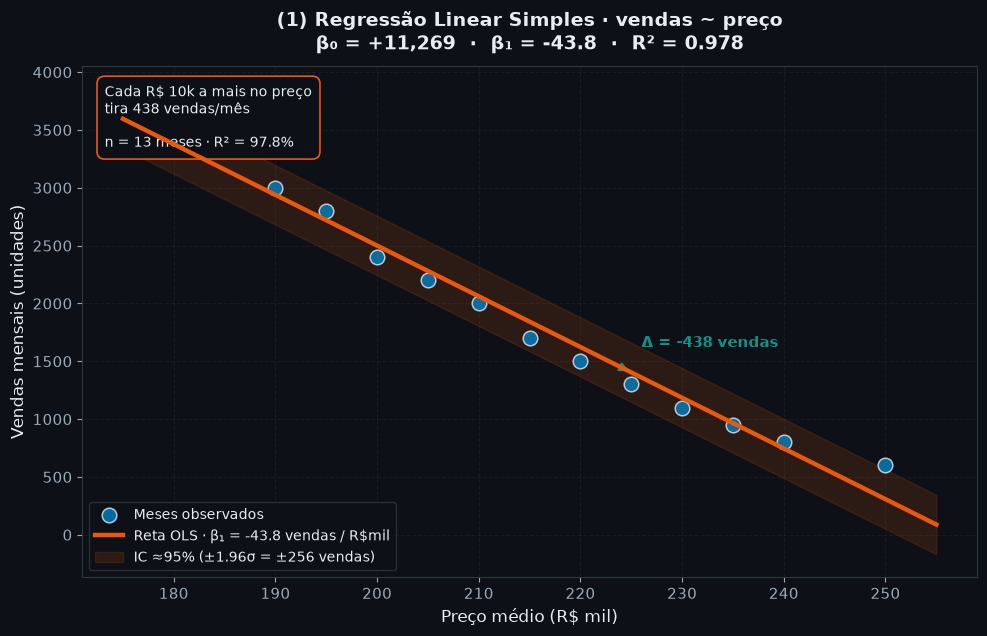

  salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l3_01_scatter_regression.png


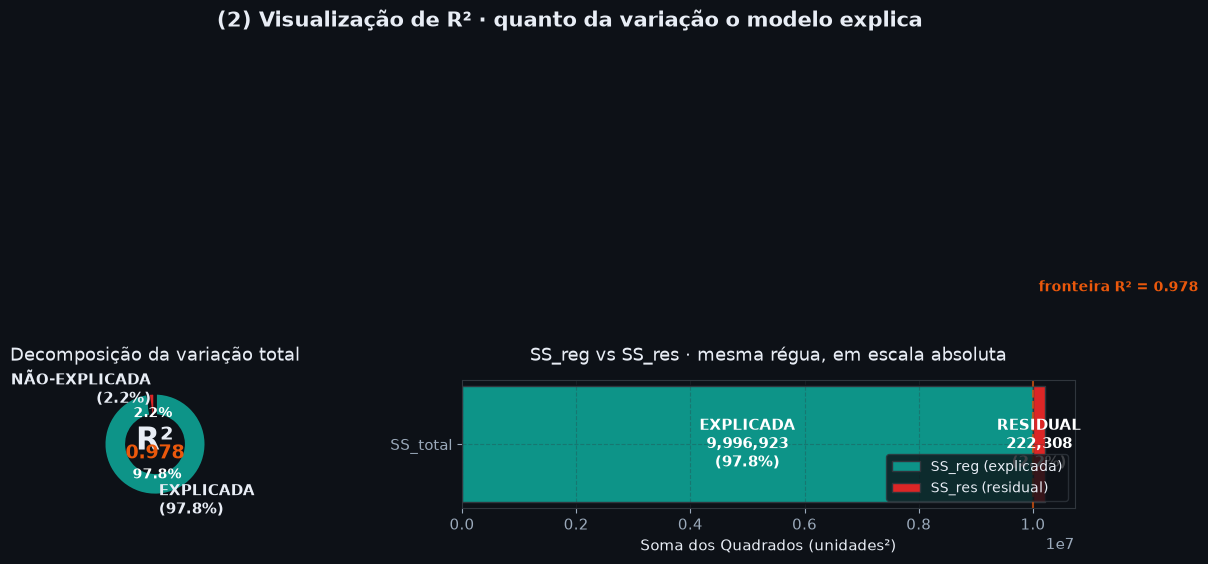

  salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l3_02_r_squared_decomposition.png


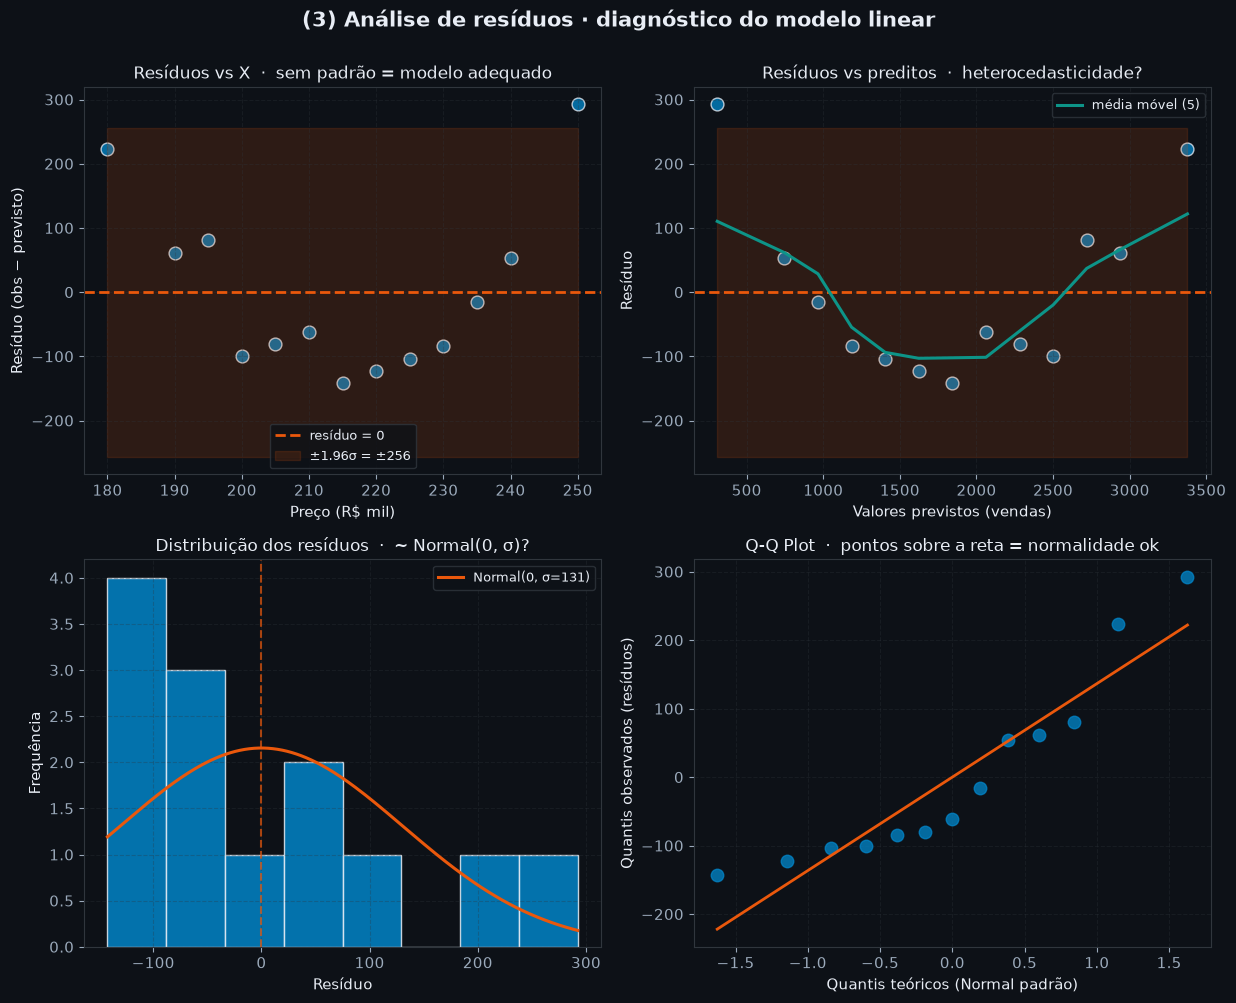

  salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l3_03_residuals_diagnostics.png

Visualizações estáticas exportadas:
  · l3_01_scatter_regression.png  (133.8 KB)
  · l3_02_r_squared_decomposition.png  (97.1 KB)
  · l3_03_residuals_diagnostics.png  (242.6 KB)

Tabela visual do R²:
  SS_total        =   10,219,231
  SS_reg (expl.)  =    9,996,923  (97.8%)
  SS_res (resid.) =      222,308  (2.2%)
  R²              = 0.978


In [8]:
# Recompute regression from multi (consistent 13 rows)
x = multi['preco_kR'].to_numpy()
y = multi['vendas_mes'].to_numpy()
beta1, beta0 = np.polyfit(x, y, 1)
yhat = beta0 + beta1 * x
residuos = y - yhat
ss_res = np.sum(residuos ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_a_check = 1 - ss_res / ss_tot

# ──────────────────────────────────────────────────────────────
# Visualizações estáticas (PNG) — entregáveis executivos
#   (1) Scatter + reta de regressão
#   (2) R² — variação explicada vs não-explicada
#   (3) Diagnóstico de resíduos
# ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

# Tema escuro + paleta validada (espelho do plotly do caderno)
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'text.color': INK,
    'grid.color': GRID,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'legend.facecolor': BG,
    'legend.edgecolor': GRID,
})

# Variáveis já calculadas no caderno (células 5 e 11):
#   x, y               — arrays da regressão simples
#   beta0, beta1       — coeficientes da regressão simples
#   yhat, residuos     — preditos e resíduos da simples
#   ss_res, ss_tot     — soma de quadrados (residual e total)
#   r2_a_check         — R² da regressão simples (recalculado em cell-11)

ss_explained = ss_tot - ss_res
sigma_r = residuos.std()

# ============================================================
# (1) SCATTER + RETA DE REGRESSÃO
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6.5))

ax.scatter(x, y, color=AZUL, s=110, alpha=0.78,
           edgecolors=INK, linewidth=1.1,
           label='Meses observados', zorder=3)

x_line = np.linspace(x.min() - 5, x.max() + 5, 220)
y_line = beta0 + beta1 * x_line
ax.plot(x_line, y_line, color=AMBAR, linewidth=3.2,
        label=f'Reta OLS · β₁ = {beta1:+.1f} vendas / R$mil', zorder=4)

ax.fill_between(x_line, y_line - 1.96 * sigma_r, y_line + 1.96 * sigma_r,
                color=AMBAR, alpha=0.14,
                label=f'IC ≈95% (±1.96σ = ±{1.96*sigma_r:.0f} vendas)', zorder=2)

ax.set_xlabel('Preço médio (R$ mil)', fontsize=12)
ax.set_ylabel('Vendas mensais (unidades)', fontsize=12)
ax.set_title('(1) Regressão Linear Simples · vendas ~ preço\n'
             f'β₀ = {beta0:+,.0f}  ·  β₁ = {beta1:+.1f}  ·  R² = {r2_a_check:.3f}',
             fontsize=14, fontweight='bold', pad=12)

ax.text(0.025, 0.965,
        f'Cada R$ 10k a mais no preço\n'
        f'tira {abs(beta1*10):,.0f} vendas/mês\n\n'
        f'n = {len(x)} meses · R² = {r2_a_check:.1%}',
        transform=ax.transAxes, va='top', ha='left',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.55',
                  facecolor=BG, edgecolor=AMBAR, linewidth=1.2))

xm = 215
ax.annotate('', xy=(xm + 10, beta0 + beta1 * (xm + 10)),
            xytext=(xm, beta0 + beta1 * xm),
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=2.2))
ax.text(xm + 11, beta0 + beta1 * (xm + 5),
        f'Δ = {beta1*10:+,.0f} vendas',
        color=TEAL, fontsize=11, fontweight='bold')

ax.legend(loc='lower left', fontsize=10, labelcolor=INK)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
out1 = OUT_DIR / 'l3_01_scatter_regression.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f"  salvo: {out1}")

# ============================================================
# (2) R² — VARIAÇÃO EXPLICADA vs NÃO-EXPLICADA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                         gridspec_kw={'width_ratios': [1, 1.4]})

# Painel A — donut (compatível com matplotlib 3.10 e 3.11)
ax = axes[0]
pie_result = ax.pie(
    [ss_explained, ss_res],
    labels=[f'EXPLICADA\n({r2_a_check:.1%})',
            f'NÃO-EXPLICADA\n({1-r2_a_check:.1%})'],
    colors=[TEAL, TIJOLO],
    startangle=90, counterclock=False,
    wedgeprops=dict(edgecolor=BG, linewidth=2.5, width=0.45),
    textprops=dict(color=INK, fontsize=11, fontweight='bold'),
    autopct='%1.1f%%')
# matplotlib >=3.11 devolve PieContainer; versão antiga devolve tupla.
if hasattr(pie_result, 'texts'):
    autotexts = pie_result.texts[1] if isinstance(pie_result.texts, list) and len(pie_result.texts) > 1 else []
else:
    _, _, autotexts = pie_result
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.text(0, 0.05, 'R²', ha='center', va='center',
        fontsize=22, fontweight='bold', color=INK)
ax.text(0, -0.18, f'{r2_a_check:.3f}', ha='center', va='center',
        fontsize=14, color=AMBAR, fontweight='bold')
ax.set_title('Decomposição da variação total',
             fontsize=13, color=INK, pad=14)

# Painel B — barra empilhada horizontal (mesma régua, escala absoluta)
ax = axes[1]
total = ss_tot
ax.barh(['SS_total'], [ss_explained], color=TEAL,
        edgecolor=GRID, linewidth=1, label='SS_reg (explicada)')
ax.barh(['SS_total'], [ss_res], left=[ss_explained], color=TIJOLO,
        edgecolor=GRID, linewidth=1, label='SS_res (residual)')

ax.text(ss_explained / 2, 0,
        f'EXPLICADA\n{ss_explained:,.0f}\n({r2_a_check:.1%})',
        ha='center', va='center',
        color='white', fontweight='bold', fontsize=11)
ax.text(ss_explained + ss_res / 2, 0,
        f'RESIDUAL\n{ss_res:,.0f}\n({1-r2_a_check:.1%})',
        ha='center', va='center',
        color='white', fontweight='bold', fontsize=11)

frac_x = ss_explained
ax.axvline(frac_x, color=AMBAR, linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(frac_x + total * 0.01, 1.05,
        f'fronteira R² = {r2_a_check:.3f}',
        color=AMBAR, fontsize=10, fontweight='bold')

ax.set_xlim(0, total * 1.05)
ax.set_xlabel('Soma dos Quadrados (unidades²)', fontsize=11)
ax.set_title('SS_reg vs SS_res · mesma régua, em escala absoluta',
             fontsize=13, color=INK, pad=14)
ax.legend(loc='lower right', fontsize=10, labelcolor=INK)
ax.grid(True, alpha=0.3, linestyle='--', axis='x')

fig.suptitle('(2) Visualização de R² · quanto da variação o modelo explica',
             fontsize=15, fontweight='bold', color=INK, y=1.02)
plt.tight_layout()
out2 = OUT_DIR / 'l3_02_r_squared_decomposition.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  salvo: {out2}")

# ============================================================
# (3) DIAGNÓSTICO DE RESÍDUOS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12.5, 10))

# A — resíduos vs X
ax = axes[0, 0]
ax.scatter(x, residuos, color=AZUL, s=85, alpha=0.78,
           edgecolors=INK, linewidth=1)
ax.axhline(0, color=AMBAR, linewidth=2, linestyle='--', label='resíduo = 0')
ax.fill_between([x.min(), x.max()],
                -1.96 * sigma_r, 1.96 * sigma_r,
                color=AMBAR, alpha=0.15, label=f'±1.96σ = ±{1.96*sigma_r:.0f}')
ax.set_xlabel('Preço (R$ mil)')
ax.set_ylabel('Resíduo (obs − previsto)')
ax.set_title('Resíduos vs X  ·  sem padrão = modelo adequado',
             fontsize=12, color=INK)
ax.legend(fontsize=9, labelcolor=INK)
ax.grid(True, alpha=0.3, linestyle='--')

# B — resíduos vs preditos (com média móvel para detectar heterocedasticidade)
ax = axes[0, 1]
ax.scatter(yhat, residuos, color=AZUL, s=85, alpha=0.78,
           edgecolors=INK, linewidth=1)
ax.axhline(0, color=AMBAR, linewidth=2, linestyle='--')
ax.fill_between([yhat.min(), yhat.max()],
                -1.96 * sigma_r, 1.96 * sigma_r,
                color=AMBAR, alpha=0.15)
ordem = np.argsort(yhat)
media_movel = pd.Series(residuos[ordem]).rolling(5, min_periods=1, center=True).mean()
ax.plot(yhat[ordem], media_movel, color=TEAL, linewidth=2.2,
        label='média móvel (5)')
ax.set_xlabel('Valores previstos (vendas)')
ax.set_ylabel('Resíduo')
ax.set_title('Resíduos vs preditos  ·  heterocedasticidade?',
             fontsize=12, color=INK)
ax.legend(fontsize=9, labelcolor=INK)
ax.grid(True, alpha=0.3, linestyle='--')

# C — histograma dos resíduos + curva normal sobreposta
ax = axes[1, 0]
n_bins = 8
ax.hist(residuos, bins=n_bins, color=AZUL, edgecolor=INK, alpha=0.85)
xs = np.linspace(residuos.min(), residuos.max(), 200)
bin_width = (residuos.max() - residuos.min()) / n_bins
ys = sp_stats.norm.pdf(xs, 0, sigma_r) * len(residuos) * bin_width
ax.plot(xs, ys, color=AMBAR, linewidth=2.2,
        label=f'Normal(0, σ={sigma_r:.0f})')
ax.axvline(0, color=AMBAR, linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_xlabel('Resíduo')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição dos resíduos  ·  ~ Normal(0, σ)?',
             fontsize=12, color=INK)
ax.legend(fontsize=9, labelcolor=INK)
ax.grid(True, alpha=0.3, linestyle='--')

# D — Q-Q plot
ax = axes[1, 1]
sp_stats.probplot(residuos, dist='norm', plot=ax)
lines = ax.get_lines()
lines[0].set_color(AZUL)
lines[0].set_marker('o')
lines[0].set_markersize(9)
lines[0].set_alpha(0.78)
lines[1].set_color(AMBAR)
lines[1].set_linewidth(2)
ax.set_xlabel('Quantis teóricos (Normal padrão)')
ax.set_ylabel('Quantis observados (resíduos)')
ax.set_title('Q-Q Plot  ·  pontos sobre a reta = normalidade ok',
             fontsize=12, color=INK)
ax.grid(True, alpha=0.3, linestyle='--')

fig.suptitle('(3) Análise de resíduos · diagnóstico do modelo linear',
             fontsize=15, fontweight='bold', color=INK, y=1.0)
plt.tight_layout()
out3 = OUT_DIR / 'l3_03_residuals_diagnostics.png'
plt.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f"  salvo: {out3}")

# ============================================================
# Resumo do que foi exportado
# ============================================================
print()
print("=" * 60)
print("Visualizações estáticas exportadas:")
print("=" * 60)
for f in [out1, out2, out3]:
    if f.exists():
        print(f"  · {f.name}  ({f.stat().st_size/1024:.1f} KB)")
    else:
        print(f"  · {f.name}  (NÃO GERADO)")
print()
print("Tabela visual do R²:")
print(f"  SS_total        = {ss_tot:>12,.0f}")
print(f"  SS_reg (expl.)  = {ss_explained:>12,.0f}  ({r2_a_check:.1%})")
print(f"  SS_res (resid.) = {ss_res:>12,.0f}  ({1-r2_a_check:.1%})")
print(f"  R²              = {r2_a_check:.3f}")